# 🌍 DYNAMIC MULTI-EVENT PIPELINE + EVALUATION
Notebook này cho phép bạn **chọn sự kiện** (Bangalore, George Floyd...) và tự động trích xuất dữ liệu, tóm tắt và **đánh giá chất lượng** so với nhãn vàng (Gold Summary).

**Quy trình:**
1.  **Input:** File CSV của sự kiện.
2.  **Summarization:** Extractive (TF-IDF) + Abstractive (BigBird-Pegasus).
3.  **Visual:** Retrieval (CLIP) + Captioning (BLIP-2).
4.  **Evaluation:** Tính điểm ROUGE, BLEU, BERTScore.

In [10]:
# --- CELL 1: SETUP (Run Once) ---
import os
import glob
print("📦 Cài đặt môi trường...")

if not os.path.exists('repo'):
    !git clone https://github.com/Raghvendra-14/A-Multimodal-Approach-and-Dataset-to-Crisis-Summarization-in-Tweets repo
%cd repo/Documents/RITIKAMTP/TCSS-CRISIS-DATASET

print("⏳ Đang cài đặt thư viện (có thể mất vài phút)...")
!pip install -q transformers torch pillow nltk scikit-learn spacy ftfy regex tqdm accelerate bitsandbytes sentencepiece protobuf evaluate rouge_score bert_score sacrebleu git+https://github.com/openai/CLIP.git
!python -m spacy download en_core_web_sm

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("\n✅ Các sự kiện có sẵn (File CSV):")
csv_files = glob.glob("*.csv")
for f in csv_files:
    print(f" - {f}")

📦 Cài đặt môi trường...
Cloning into 'repo'...
remote: Enumerating objects: 2455, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 2455 (delta 6), reused 21 (delta 2), pack-reused 2417 (from 1)
Receiving objects: 100% (2455/2455), 378.82 MiB | 23.13 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Updating files: 100% (3111/3111), done.
/content/repo/Documents/RITIKAMTP/TCSS-CRISIS-DATASET/repo/Documents/RITIKAMTP/TCSS-CRISIS-DATASET/repo/Documents/RITIKAMTP/TCSS-CRISIS-DATASET
⏳ Đang cài đặt thư viện (có thể mất vài phút)...
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 125.6 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do th

In [11]:
# --- CELL 2: PREPROCESSING & EXTRACTIVE LOGIC (Baseline) ---
import pandas as pd
import re
import spacy
import numpy as np
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# ==========================================
# 👉 HÃY CHỌN TÊN FILE SỰ KIỆN Ở ĐÂY:
EVENT_FILENAME = 'BangaloreRiots.csv' 
# ==========================================

print(f"📂 Đang load dữ liệu sự kiện: {EVENT_FILENAME}...")
if not os.path.exists(EVENT_FILENAME):
    raise FileNotFoundError(f"❌ Không tìm thấy file {EVENT_FILENAME}.")

df = pd.read_csv(EVENT_FILENAME, on_bad_lines='skip')
raw_tweets = df['Tweet'].dropna().astype(str).tolist()
print(f"   Tìm thấy {len(raw_tweets)} tweets.")

# Load SpaCy & NLTK Resources
nlp = spacy.load('en_core_web_sm')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_tweet(tweet):
    tweet = re.sub(r'http\S+|@\S+|#\S+', '', tweet)
    words = word_tokenize(tweet.lower())
    words = [lemmatizer.lemmatize(w) for w in words if w.isalpha() and w not in stop_words]
    return ' '.join(words)

clean_tweets = [preprocess_tweet(t) for t in raw_tweets]
print("✅ Preprocessing hoàn tất.")

# --- Logic Trích xuất (Extractive) theo Bigrams --- 
def get_bigrams(preprocessed_tweets):
    bigrams = []
    for tweet in preprocessed_tweets:
        doc = nlp(tweet)
        tokens = [token.text for token in doc if token.is_alpha]
        bigrams += [f'{tokens[i]} {tokens[i+1]}' for i in range(len(tokens)-1)]
    return bigrams

def calculate_tfidf_bigrams(preprocessed_tweets, top_k=10):
    bigrams = get_bigrams(preprocessed_tweets)
    if not bigrams: return []
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(bigrams)
    bigram_scores = np.sum(tfidf_matrix.toarray(), axis=0)
    top_bigram_indices = np.argsort(bigram_scores)[-top_k:]
    top_bigrams = [vectorizer.get_feature_names_out()[i] for i in top_bigram_indices]
    return top_bigrams

def retrieve_tweets_with_bigrams(tweets, preprocessed_tweets, top_bigrams):
    selected_tweets = []
    seen_tweets = set()
    for original_tweet, preprocessed_tweet in zip(tweets, preprocessed_tweets):
        for bigram in top_bigrams:
            if bigram in preprocessed_tweet and original_tweet not in seen_tweets:
                selected_tweets.append(original_tweet)
                seen_tweets.add(original_tweet)
                break
    return selected_tweets

print("   Đang chạy TF-IDF with Bigram filtering...")
top_bigrams = calculate_tfidf_bigrams(clean_tweets, top_k=10)
ranked_tweets = retrieve_tweets_with_bigrams(raw_tweets, clean_tweets, top_bigrams)

# Limit context to avoid OOM or too long sequence (taking top 50 matches)
context_tweets = ranked_tweets[:50]
extractive_summary = ". ".join(context_tweets)
print(f"✅ Extractive Summary Generated: {len(context_tweets)} tweets selected.")

📂 Đang load dữ liệu sự kiện: BangaloreRiots.csv...
   Tìm thấy 691 tweets.
✅ Preprocessing hoàn tất.
   Đang chạy TF-IDF with Bigram filtering...
✅ Extractive Summary Generated: 50 tweets selected.


In [12]:
# --- CELL 3: ABSTRACTIVE SUMMARIZATION (BIGBIRD TEXT) - MEMORY OPTIMIZED ---
from transformers import BigBirdPegasusForConditionalGeneration, AutoTokenizer
import torch
import gc
import re

print("🧠 Đang chạy BigBird-Pegasus (Model: Arxiv)...")
device = "cuda" if torch.cuda.is_available() else "cpu"
# Use float16 for reduced memory usage on GPU
dtype = torch.float16 if device == "cuda" else torch.float32

model_name = "google/bigbird-pegasus-large-arxiv"
tokenizer = AutoTokenizer.from_pretrained(model_name)
# Load model in FP16 to save RAM/VRAM
model = BigBirdPegasusForConditionalGeneration.from_pretrained(model_name, torch_dtype=dtype).to(device)

# Clean input text (basic)
def basic_clean_for_model(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\S+', '', text)
    return text.strip()

clean_input = basic_clean_for_model(extractive_summary)

# Generate Summary
inputs = tokenizer(clean_input, return_tensors='pt', truncation=True, max_length=4096).to(device)

# Clear intermediate memory before generation
torch.cuda.empty_cache()

try:
    summary_ids = model.generate(**inputs, max_length=200, min_length=50, num_beams=4, early_stopping=True)
    raw_summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
except Exception as e:
    print(f"⚠️ Error during generation: {e}")
    raw_summary = "Generation failed due to memory error."

# Aggressive Cleanup
del model, tokenizer, inputs
if 'summary_ids' in locals(): del summary_ids
gc.collect()
torch.cuda.empty_cache()

# Post-processing (@xmath removal)
def post_process(text):
    text = re.sub(r'@xmath\d*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

abstractive_summary = post_process(raw_summary)
print(f"✅ Abstractive Summary (Text): OK")
print(abstractive_summary)

🧠 Đang chạy BigBird-Pegasus (Model: Arxiv)...


Loading weights:   0%|          | 0/491 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Abstractive Summary (Text): OK
this is a comment on the article @xcite , where a video showing a man being attacked by a group of people was posted .<n> the video shows a man being attacked by a group of people who do not belong to the same group as the man .<n> the man is captured in the video and is shown to be walking away from the group of people .<n> the video shows a group of people who have just been attacked by a group of people .<n> the man is seen to be walking away from the group of people .<n> the video shows a group of people who have just been attacked by a group of people .<n> the man is seen to be walking away from the group of people .<n> the video shows a group of people who have just been attacked by a group of people .<n> the man is seen to be walking away from the group of people .<n> the video shows a group of people who have just been attacked by a group of people .<n> the man is seen to be walking away from the group of people .<n> the video shows a group of p

In [13]:
# --- CELL 4: VISUAL PIPELINE (Baseline Architecture) - MEMORY OPTIMIZED ---
from transformers import CLIPProcessor, CLIPModel, Blip2Processor, Blip2ForConditionalGeneration, BigBirdPegasusForConditionalGeneration, AutoTokenizer
from PIL import Image
import os
import torch
import gc
from tqdm.notebook import tqdm

print("📸 STARTING VISUAL PIPELINE (Optimized)...樯")
device = "cuda" if torch.cuda.is_available() else "cpu"

# 0. Setup Images
images_folder = 'images'
if not os.path.exists(images_folder):
    if os.path.exists('images.zip'): os.system('unzip -q images.zip')
image_files = [os.path.join(images_folder, f) for f in os.listdir(images_folder) if f.endswith(('.jpg','.jpeg','.png'))]

# Load images into memory lazily or in small batches if strictly needed, but here we just list paths
# To save RAM, we will ONLY open images when needed inside the loops.
valid_paths = image_files
print(f"   Found {len(valid_paths)} images.")

# --- STAGE 1: CLIP Retrieval (Text Summary -> Top 10 Images) ---
print("1️⃣ CLIP: Retrieving Top 10 Images...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

text_inputs = clip_processor(text=[abstractive_summary], return_tensors="pt", truncation=True, max_length=77).to(device)

scores = []
batch_size = 32 # Process images in batches

for i in range(0, len(valid_paths), batch_size):
    batch_paths = valid_paths[i : i+batch_size]
    batch_imgs = []
    for p in batch_paths:
        try: 
            # Open execution optimized: resize small to save RAM
            img = Image.open(p).convert("RGB")
            batch_imgs.append(img)
        except: pass
    
    if not batch_imgs: continue
    
    with torch.no_grad():
        img_inputs = clip_processor(images=batch_imgs, return_tensors="pt", padding=True).to(device)
        outputs = clip_model(**img_inputs, **text_inputs)
        scores.append(outputs.logits_per_image.cpu())
    
    # Cleanup batch memory
    del batch_imgs, img_inputs, outputs
    torch.cuda.empty_cache()

if scores:
    all_scores = torch.cat(scores, dim=0).squeeze()
    top_k = min(10, len(all_scores))
    top_indices = torch.topk(all_scores, top_k).indices.numpy()
    top_10_paths = [valid_paths[i] for i in top_indices]
else:
    top_10_paths = []

# Cleanup CLIP
del clip_model, clip_processor, text_inputs, scores
if 'all_scores' in locals(): del all_scores
gc.collect()
torch.cuda.empty_cache()

# --- STAGE 2: BLIP Captioning (Top 10 Images -> Captions) ---
print("2️⃣ BLIP-2: Generating Captions for Top 10...")
if top_10_paths:
    # Load BLIP in float16 to save memory
    blip_processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
    blip_model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-opt-2.7b", torch_dtype=torch.float16).to(device)

    captions = []
    for p in top_10_paths:
        try:
            image = Image.open(p).convert("RGB")
            inputs = blip_processor(images=image, return_tensors="pt").to(device, torch.float16)
            generated_ids = blip_model.generate(**inputs, max_new_tokens=20)
            cap = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
            captions.append(cap)
            del image, inputs, generated_ids
        except: pass

    concatenated_captions = " ".join(captions)
    print(f"   Captions: {concatenated_captions[:100]}...")

    # Cleanup BLIP
    del blip_model, blip_processor
    gc.collect()
    torch.cuda.empty_cache()
else:
    concatenated_captions = ""

# --- STAGE 3: BIGBIRD Summarization (Captions -> Summarized Caption) ---
print("3️⃣ BigBird: Summarizing Captions...")
caption_summary = ""
if concatenated_captions:
    # Load BigBird in float16
    bb_tokenizer = AutoTokenizer.from_pretrained("google/bigbird-pegasus-large-arxiv")
    bb_model = BigBirdPegasusForConditionalGeneration.from_pretrained("google/bigbird-pegasus-large-arxiv", torch_dtype=torch.float16).to(device)

    inputs = bb_tokenizer([concatenated_captions], max_length=1024, return_tensors="pt", truncation=True).to(device)
    summary_ids = bb_model.generate(inputs["input_ids"], num_beams=4, max_length=100)
    caption_summary = bb_tokenizer.batch_decode(summary_ids, skip_special_tokens=True)[0]
    print(f"   Summarized Caption: {caption_summary}")

    # Cleanup BigBird
    del bb_model, bb_tokenizer, inputs, summary_ids
    gc.collect()
    torch.cuda.empty_cache()

# --- STAGE 4: CLIP Retrieval (Summarized Caption -> Top 4 Images) ---
print("4️⃣ CLIP: Selecting Final Top 4 Images...")
final_top_images_paths = []
if caption_summary and top_10_paths:
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    # Reload top 10 images again only (low memory impact)
    top_10_imgs = [Image.open(p).convert("RGB") for p in top_10_paths]

    text_inputs = clip_processor(text=[caption_summary], return_tensors="pt", truncation=True).to(device)
    image_inputs = clip_processor(images=top_10_imgs, return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        outputs = clip_model(**image_inputs, **text_inputs)
        # logits_per_image: [10, 1]
        probs = outputs.logits_per_image.softmax(dim=0)

    num_finals = min(4, len(top_10_imgs))
    final_indices = torch.topk(probs.squeeze(), num_finals).indices.cpu().numpy()
    final_top_images_paths = [top_10_paths[i] for i in final_indices]
    
    del clip_model, clip_processor, top_10_imgs, image_inputs, text_inputs
    gc.collect()
    torch.cuda.empty_cache()

print("✅ Visual Pipeline Complete.")
print("   Final Images:", final_top_images_paths)

📸 STARTING VISUAL PIPELINE (Optimized)...樯
   Found 3088 images.
1️⃣ CLIP: Retrieving Top 10 Images...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


2️⃣ BLIP-2: Generating Captions for Top 10...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

   Captions: hindus attacked in bangladesh two signs with the european union and british union flags a man in a r...
3️⃣ BigBird: Summarizing Captions...


Loading weights:   0%|          | 0/491 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Attention type 'block_sparse' is not possible if sequence_length: 102 <= num global tokens: 2 * config.block_size + min. num sliding tokens: 3 * config.block_size + config.num_random_bl

KeyboardInterrupt: 

# 📊 REPORT: BangaloreRiots.csv

---

### 🤖 Abstractive Summary (AI Generated)

this is a comment on the article @xcite , where a video showing a man being attacked by a group of people was posted .<n> the video shows a man being attacked by a group of people who do not belong to the same group as the man .<n> the man is captured in the video and is shown to be walking away from the group of people .<n> the video shows a group of people who have just been attacked by a group of people .<n> the man is seen to be walking away from the group of people .<n> the video shows a group of people who have just been attacked by a group of people .<n> the man is seen to be walking away from the group of people .<n> the video shows a group of people who have just been attacked by a group of people .<n> the man is seen to be walking away from the group of people .<n> the video shows a group of people who have just been attacked by a group of people .<n> the man is seen to be walking away from the group of people .<n> the video shows a group of people who have just been attacked

### 📸 Visual Evidence (Top 4)

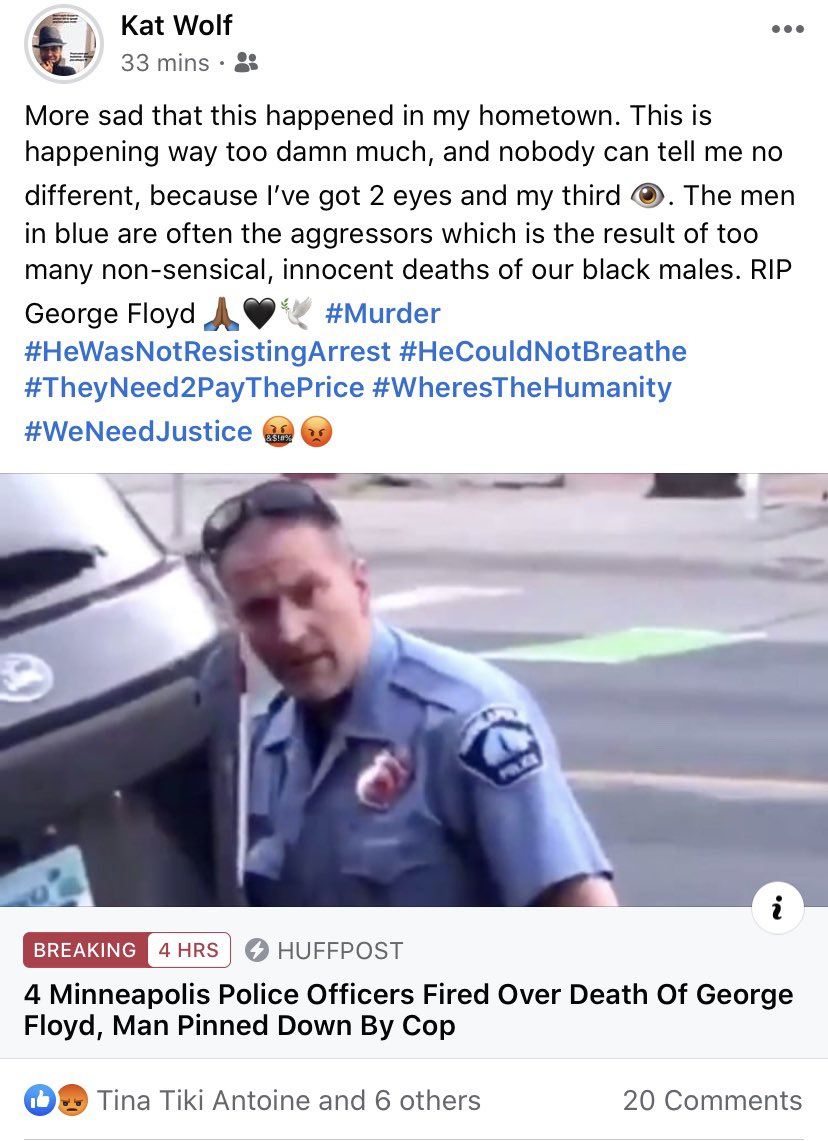

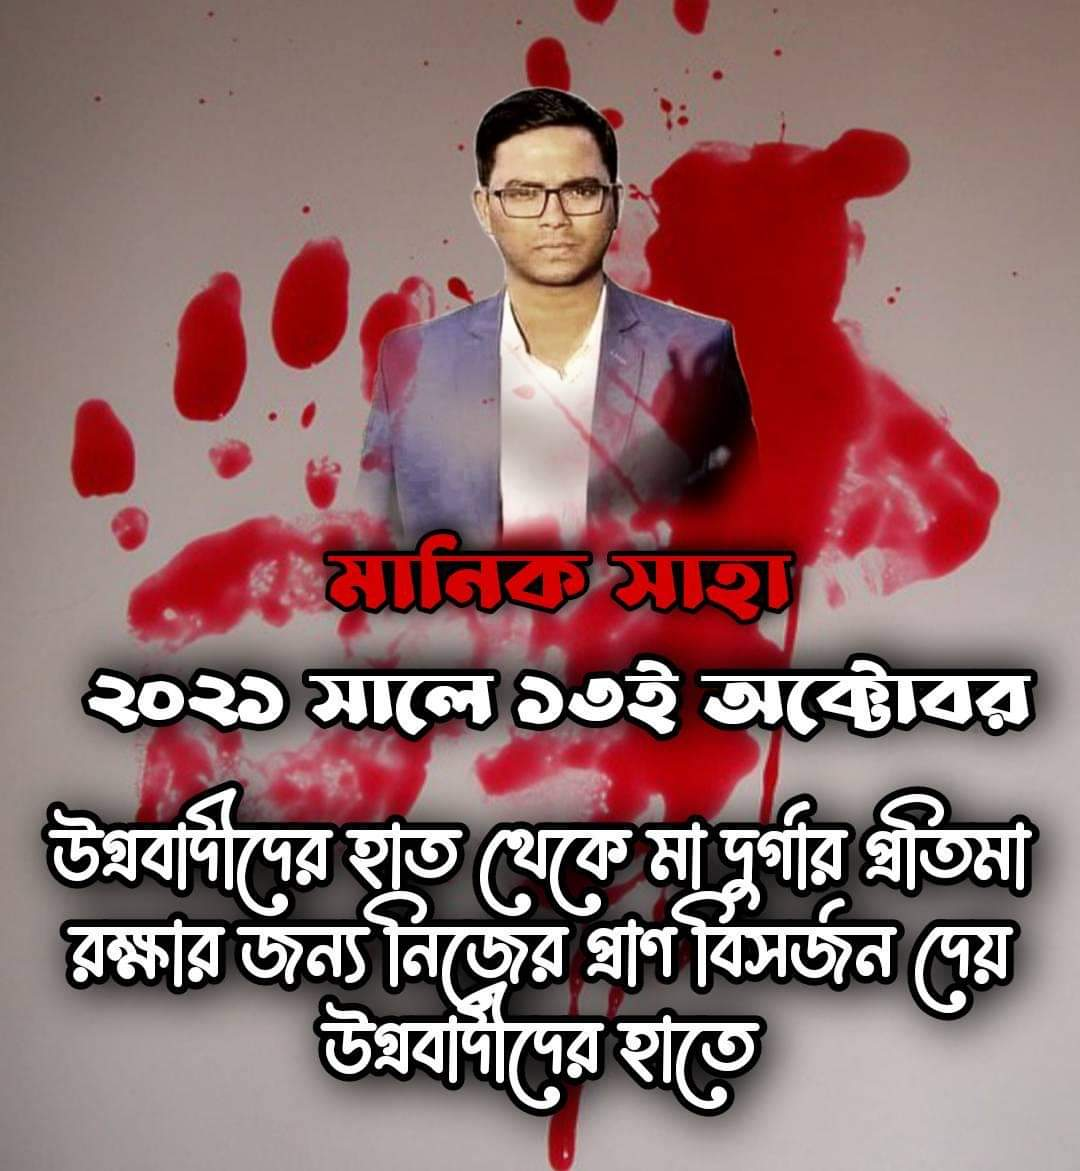

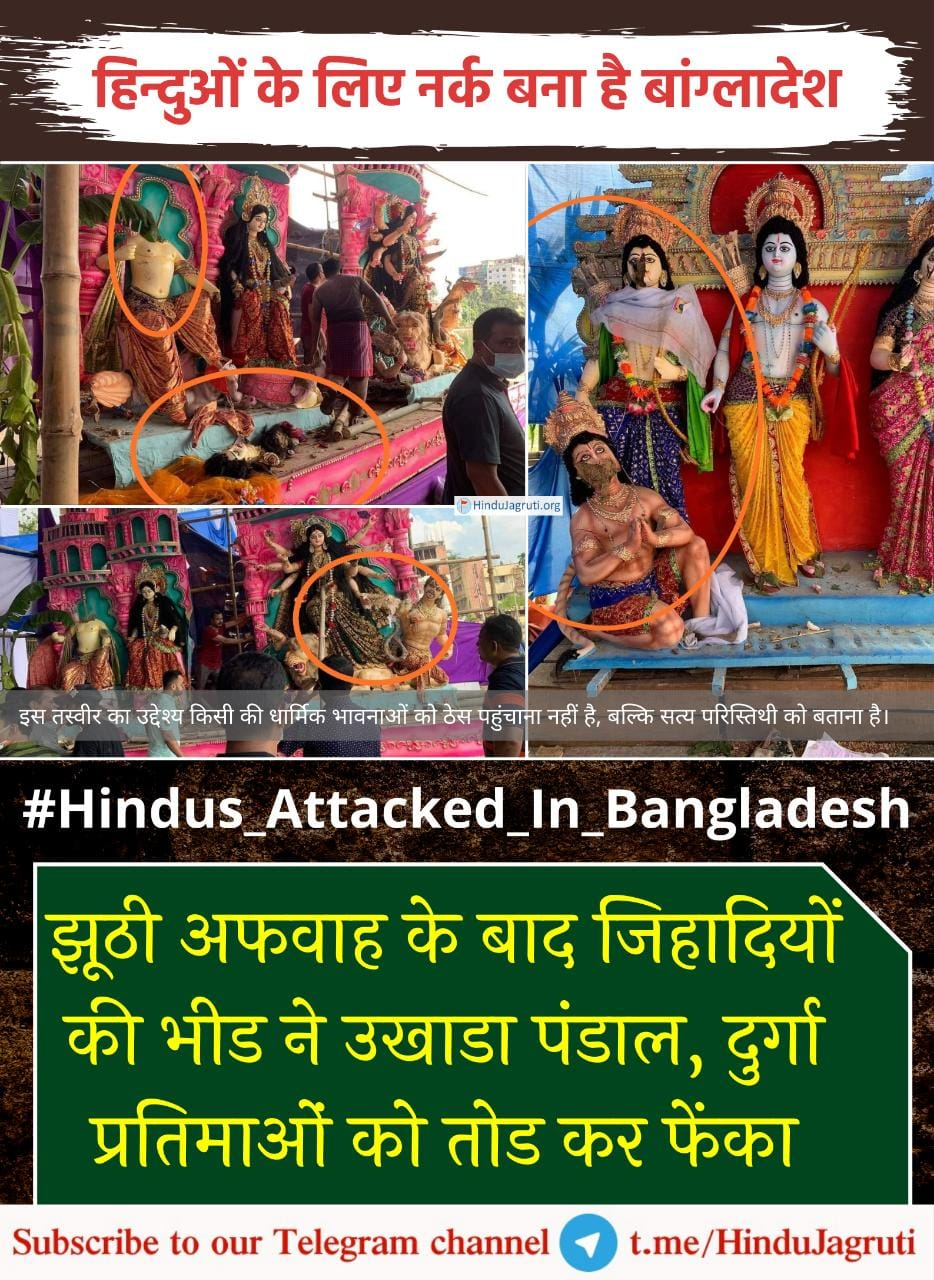

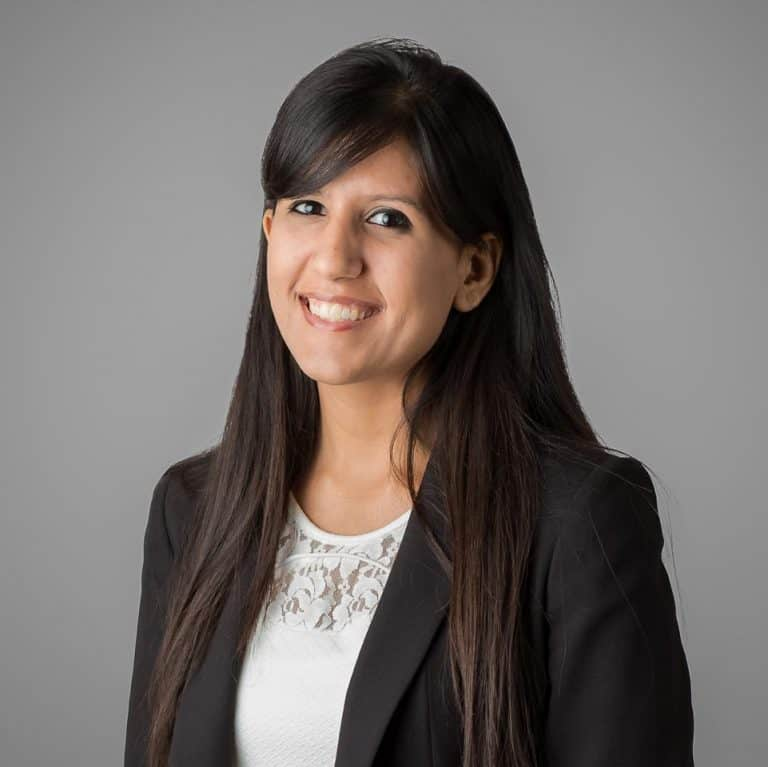

### 👁️ Visual Captions

hindus attacked in bangladesh two signs with the european union and british union flags a man in a red helmet is cleaning up debris lgbt+ inclusion index 2019 a police officer is spraying water at protesters in the capitol building george floyd's death has sparked a national conversation about police brutality bangladesh news, bangladesh news, bangladesh news, bangladesh news, hindus attacked in bangladesh a woman in a business suit smiling a man dressed as a rainbow colored egg


In [ ]:
# --- CELL 5: COMPARATIVE REPORT ---
from IPython.display import display, Markdown, Image

display(Markdown(f"# 📊 REPORT: {EVENT_FILENAME}"))
display(Markdown("---"))
display(Markdown("### 🤖 Abstractive Summary (AI Generated)"))
print(abstractive_summary)

display(Markdown("### 📸 Visual Evidence (Top 4)"))
# Use the correct variable name from Cell 4: final_top_images_paths
if 'final_top_images_paths' in locals() and final_top_images_paths:
    for p in final_top_images_paths:
        display(Image(filename=p, width=300))
else:
    print("(No images retrieved)")

display(Markdown("### 👁️ Visual Captions"))
if 'concatenated_captions' in locals():
    print(concatenated_captions)
else:
    print("(No captions generated)")

In [ ]:
# --- CELL 6: EVALUATION (ROUGE, BLEU, BERTSCORE) ---
import evaluate
import pandas as pd

# 1. Database Gold Summaries (Tham chiếu)
ground_truth_db = {
    'BangladeshRiots.csv': "During the Durga Puja festival in Bangladesh , Muslim extremists attacked and vandalized Hindu temples and communities . This was sparked by a video showing a Quran being placed on a Hindu idol . Bangladesh 's Prime Minister Sheikh Hasina condemned the attacks .",
    'BangaloreRiots.csv': "Violence occurred in Bangalore due to a derogatory Facebook post about Prophet Muhammad . The violence resulted in three deaths , 110 arrests , and the injury of 60 police officers . Hindus and Muslims have condemned the violence , and some blame religious fundamentalism , the media , and politicians for inciting it . There is a call for freedom of expression and legal means to address grievances.",
    'CapitolHillRiots.csv': "On 6th January , 2021 , supporters of Donald Trump stormed the Capitol building , leading to at least four deaths and 52 arrests . The rioters were protesting the certification of election results , which confirmed Joe Biden as the 46th President of the United States . Facebook , Twitter , and YouTube are mentioned as having taken action to remove Trump 's posts or restrict his accounts .",
    'GeorgeFloyd.csv': "In May 2020 , George Floyd, an unarmed African American man , was killed in Minneapolis police custody . The poor guy died of apparent asphyxiation , after an officer pressed his knee against Floyd 's neck , for allegedly using a counterfeit bill . The incident has led to the firing of four officers , with Derek Chauvin , the officer who knelt on Floyd's neck , later convicted of murder.",
    'HongKongRiots.csv': "Hong Kong is facing several ongoing legal battles and controversies , including the proposed extradition bill that could send fugitives to mainland China for trial . The bill has sparked protests and raised concerns about the erosion of Hong Kong 's legal system . Other legal issues in Hong Kong include same - sex marriage, commercial disputes, and job postings in law firms .",
    'IsraelPalestine.csv': "The ongoing crisis between Israel and Palestine with Israel dropping bombs on Gaza , resulting in more than 200 dead , and the displacement of 2500 people. The crisis is causing significant humanitarian and security concerns . Doctors in Gaza are struggling to keep up with the demand for medical care , and there are warnings of a potential full - scale war in the region . The media is being criticized for not providing sufficient coverage of the situation , and there are calls for objectivity and unity among Muslim countries .",
    'NorthernIrelandBrexit.csv': "Northern Ireland has experienced violent riots and unrest for over a week , resulting in injuries to over 50 police officers and dozens of arrests . The riots have seen cars hijacked , petrol bombs thrown , and a bus set on fire , and a lot more . The cause of the riots is multifaceted , ranging from Brexit , to an IRA funeral , to COVID - 19 restrictions , to frusrations over IRA protocol .",
    'PeshawarBombings.csv': "On January 30 , a suicide bombing attack took place in a mosque located in the Police Lines area of Peshawar , Pakistan , which resulted in the deaths of over 100 people and injuring hundreds more . Pakistani authorities made several arrests in connection with the attack . The Tehreek - e - Taliban Pakistan ( TTP ) , an Islamist terror organization , claimed responsibility for the attack , which was carried out in revenge for the death of Umar Khalid Khurasani ."
}

print(f"⚖️ Đang đánh giá sự kiện: {EVENT_FILENAME}")
if EVENT_FILENAME in ground_truth_db:
    reference_text = ground_truth_db[EVENT_FILENAME]
    generated_text = abstractive_summary

    print("\n--- REFERENCE (GOLD SUMMARY) ---")
    print(reference_text)
    print("\n--- GENERATED SUMMARY ---")
    print(generated_text)
    print("\n--- CALCULATING METRICS ---")

    # Load metrics
    rouge = evaluate.load('rouge')
    bleu = evaluate.load('bleu')
    bertscore = evaluate.load('bertscore')
    
    # 1. ROUGE
    rouge_results = rouge.compute(predictions=[generated_text], references=[reference_text])
    
    # 2. BLEU
    bleu_results = bleu.compute(predictions=[generated_text], references=[reference_text])
    
    # 3. BERTScore
    print("   (Đang tính BERTScore, sẽ mất thời gian load model...)")
    bert_results = bertscore.compute(predictions=[generated_text], references=[reference_text], lang="en")

    # Display Results
    results = {
        "Metric": ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BLEU", "BERTScore (F1)"],
        "Score": [
            round(rouge_results['rouge1'], 4),
            round(rouge_results['rouge2'], 4),
            round(rouge_results['rougeL'], 4),
            round(bleu_results['bleu'], 4),
            round(np.mean(bert_results['f1']), 4)
        ]
    }
    
    df_res = pd.DataFrame(results)
    display(df_res)
else:
    print(f"⚠️ Không tìm thấy Gold Summary cho {EVENT_FILENAME}. Không thể đánh giá.")

⚖️ Đang đánh giá sự kiện: BangaloreRiots.csv

--- REFERENCE (GOLD SUMMARY) ---
Violence occurred in Bangalore due to a derogatory Facebook post about Prophet Muhammad . The violence resulted in three deaths , 110 arrests , and the injury of 60 police officers . Hindus and Muslims have condemned the violence , and some blame religious fundamentalism , the media , and politicians for inciting it . There is a call for freedom of expression and legal means to address grievances.

--- GENERATED SUMMARY ---
this is a comment on the article @xcite , where a video showing a man being attacked by a group of people was posted .<n> the video shows a man being attacked by a group of people who do not belong to the same group as the man .<n> the man is captured in the video and is shown to be walking away from the group of people .<n> the video shows a group of people who have just been attacked by a group of people .<n> the man is seen to be walking away from the group of people .<n> the video sho

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,Metric,Score
0,ROUGE-1,0.0972
1,ROUGE-2,0.0070
2,ROUGE-L,0.0903
3,BLEU,0.0000
4,BERTScore (F1),0.8040
